# Classification Performance Analysis (Positive vs. Negative Cases)
This notebook analyzes the classification performance of different deep learning models on the CheXpert dataset.
We compare performance across conditions and models, examining F1 Score, Balanced Error Rate (BER), Precision, and Recall.

### Import Necessary Libraries
We import standard data science libraries for data manipulation, visualization, and evaluation.

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset
We load the processed classification results to analyze model performance across different conditions.

The dataset `model_metrics.csv` can be downloaded from the project repository:  
**Dataset Source:** [📂 GitHub - model_metrics.csv](https://github.com/johnmtayag/DSC288R_Capstone/tree/main/results/model_metrics)

Ensure that the file is saved in the appropriate directory before running the notebook.

In [2]:
# Load classification results CSV file
df_metrics = pd.read_csv('results/model_metrics/model_metrics.csv') # Update with actual file path if required

# Display first few rows to verify correct loading
df_metrics.head()

,results_df_name,model_name,metric_category,condition,metric,value
0,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,TP,1080.000000
1,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,FP,4140.000000
2,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,FN,3680.000000
3,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,TN,30471.000000
4,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,TPR,0.226891


In [3]:
# List unique values in each column
for col in df_metrics.columns:
    print(col, df_metrics[col].unique())

results_df_name ['test_results' 'valid_rad_results' 'test_rad_results']
model_name ['resnet_base224' 'resnet_base224_enhanced' 'densenet_base224'
 'densenet_base224_enhanced' 'resnet_base384' 'resnet_base384_enhanced'
 'densenet_base384' 'densenet_base384_enhanced' 'resnet_base512'
 'resnet_base512_enhanced' 'densenet_base512' 'densenet_base512_enhanced']
metric_category ['positive_vs_negative' 'certain_vs_uncertain']
condition ['Cardiomegaly' 'Consolidation' 'Edema' 'Atelectasis' 'Pleural Effusion']
metric ['TP' 'FP' 'FN' 'TN' 'TPR' 'FPR' 'FNR' 'TNR' 'Precision' 'Recall' 'BER'
 'F1 Score' 'TPU' 'FPU' 'FNU' 'TNU' 'FPU_AP' 'FPU_AN' 'TNU_AP' 'TNU_AN'
 'prec' 'recall' 'f1_score']
value [1.08000000e+03 4.14000000e+03 3.68000000e+03 ... 8.30188679e-01
 3.54479419e-01 4.23076923e-01]


In [4]:
# Filter dataset by analysis type
df_test_results = df_metrics[df_metrics["results_df_name"] == "test_results"]  # Main analysis dataset
df_test_rad_results = df_metrics[df_metrics["results_df_name"] == "test_rad_results"]  # Generalization check
df_valid_rad_results = df_metrics[df_metrics["results_df_name"] == "valid_rad_results"]  # Validation dataset

In [5]:
# Focus on classification task: positive vs negative labels
df_test_results = df_test_results[df_test_results["metric_category"] == "positive_vs_negative"]
df_test_rad_results = df_test_rad_results[df_test_rad_results["metric_category"] == "positive_vs_negative"]
df_valid_rad_results = df_valid_rad_results[df_valid_rad_results["metric_category"] == "positive_vs_negative"]

## Data Aggregation and Transformation
We reshape the dataset to compare model performance across conditions.

In [6]:
# Aggregate and transform data
def pivot_existing_metrics(df):
    """Transforms dataset into structured format using precomputed metrics."""
    return df.pivot(index=["model_name", "condition"], columns="metric", values="value").reset_index()

In [7]:
# Aggregate and transform data
df_test_pivot = pivot_existing_metrics(df_test_results)
df_test_rad_pivot = pivot_existing_metrics(df_test_rad_results)
df_valid_rad_pivot = pivot_existing_metrics(df_valid_rad_results)

**Summary:**
- The dataset is transformed into a structured format for better comparison of model performance.
- We apply the transformation function to generate pivoted tables for test, generalization, and validation datasets.
- These transformed datasets enable direct metric comparisons across models and conditions.

## F1 Score
This section analyzes the model performance based on **F1 Score**, which balances **Precision and Recall** to evaluate classification effectiveness. 

- **Higher F1 Scores** indicate better classification performance.
- We compare different models across all conditions.

In [8]:
# Select the best-performing model per condition based on F1 Score
best_models = df_test_pivot.loc[df_test_pivot.groupby("condition")["F1 Score"].idxmax()]

<Figure size 1200x600 with 0 Axes>

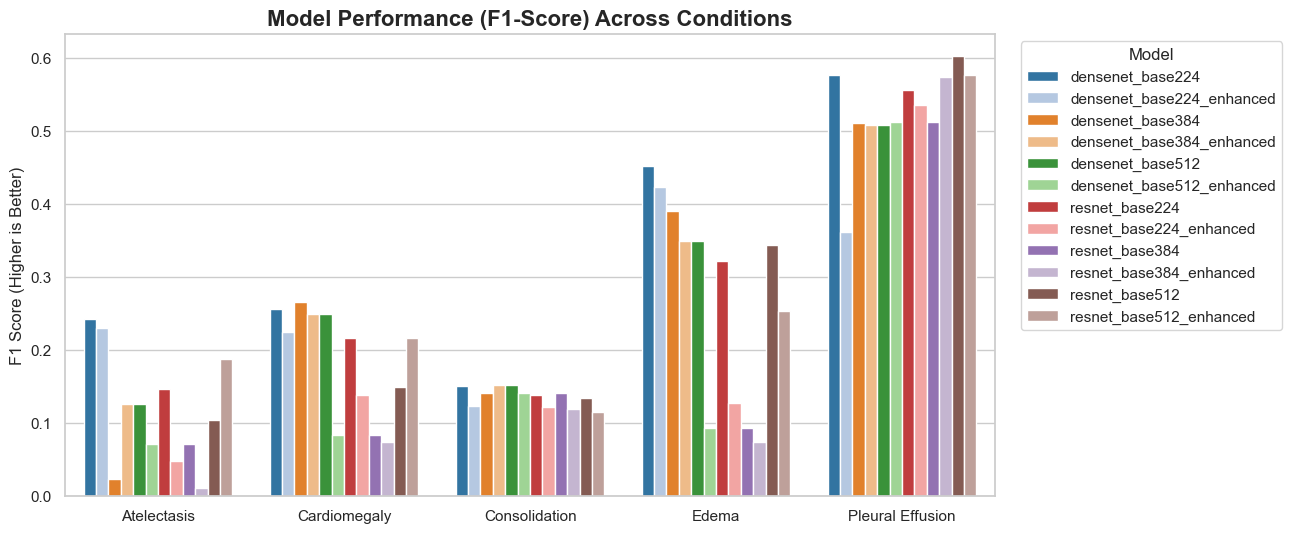

In [9]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Bar plot of F1-Score across models and conditions
plt.figure(figsize=(12,6))
ax = sns.barplot(data=df_test_pivot, x="condition", y="F1 Score", hue="model_name", palette="tab20")

plt.xticks(rotation=0)
plt.title("Model Performance (F1-Score) Across Conditions", fontsize=16, fontweight='bold')
plt.ylabel("F1 Score (Higher is Better)")
plt.xlabel("")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc='upper left')

## Balanced Error Rate (BER)
This section evaluates model performance based on **Balanced Error Rate (BER)**, which accounts for class imbalance by averaging the error rates of both positive and negative classes.

- **Lower BER values** indicate better classification performance.
- We compare different models across all conditions to assess generalization.

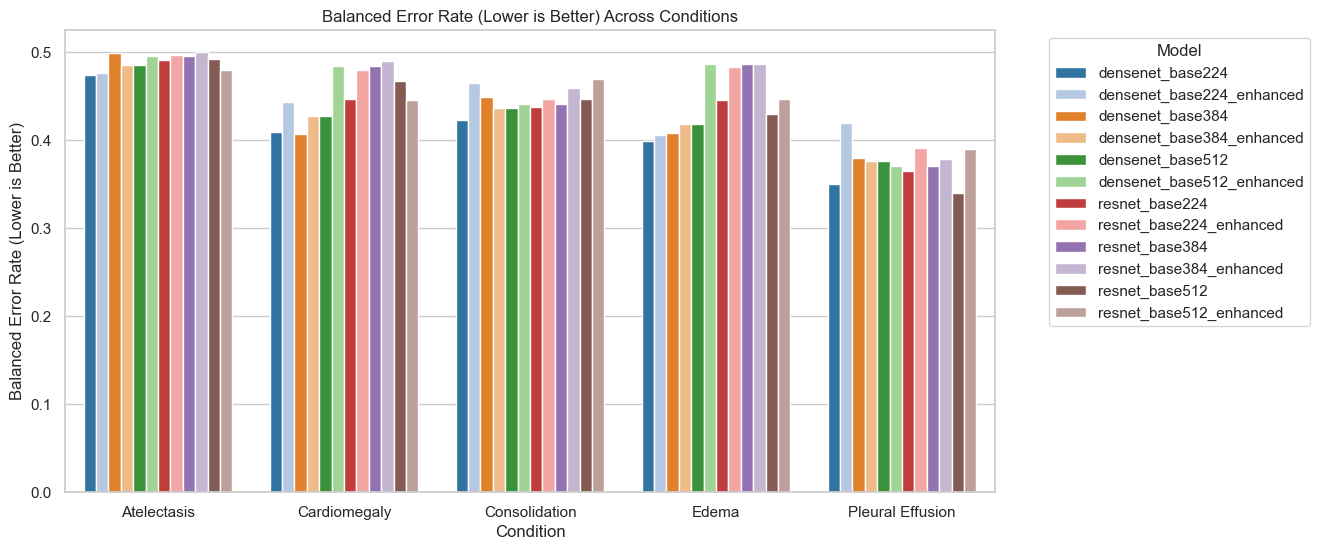

In [10]:
# Bar plot of Balanced Error Rate (BER) across conditions
plt.figure(figsize=(12,6))
ax = sns.barplot(data=df_test_pivot, x="condition", y="BER", hue="model_name", palette="tab20")

plt.xticks(rotation=0)
plt.title("Balanced Error Rate (Lower is Better) Across Conditions")
plt.ylabel("Balanced Error Rate (Lower is Better)")
plt.xlabel("Condition")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

## Precision and Recall
This section evaluates model classification performance using **Precision** and **Recall**, which measure how well models distinguish positive cases.

- **Precision**: The proportion of correctly predicted positive cases among all predicted positives.
- **Recall**: The proportion of actual positive cases correctly identified by the model.

A **higher Precision** reduces false positives, while a **higher Recall** reduces false negatives. We analyze both metrics across different models and conditions.

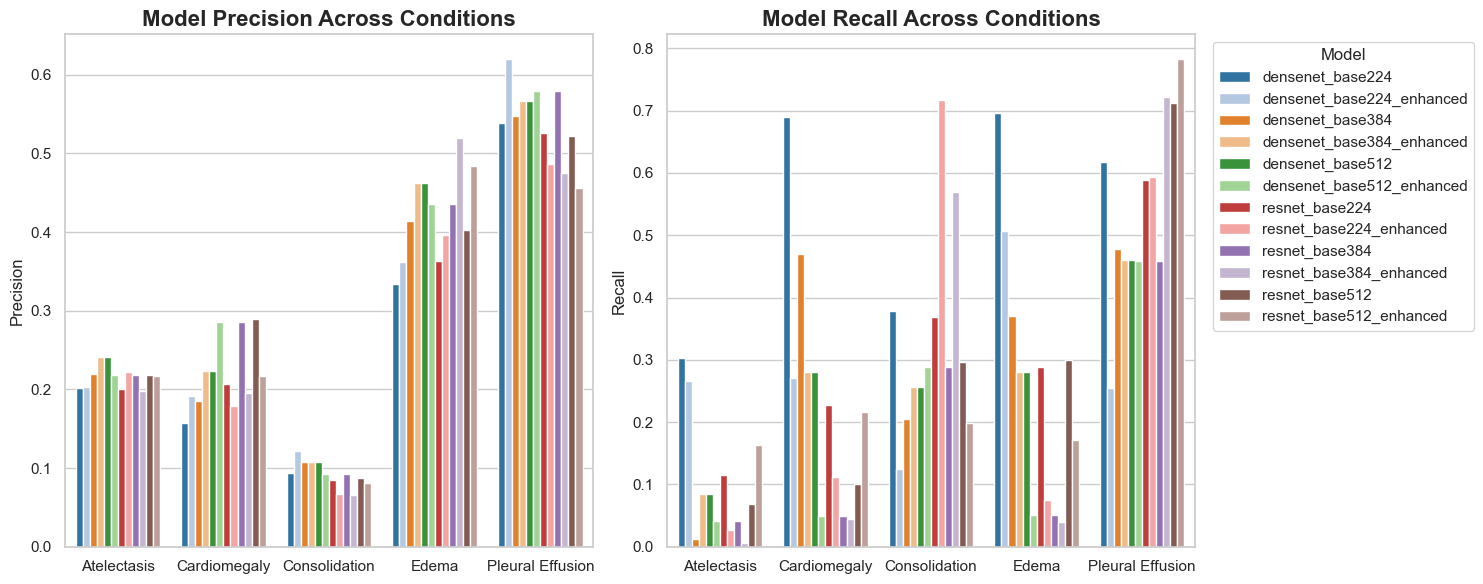

In [11]:
# Bar plots for Precision and Recall side by side
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Precision plot
sns.barplot(data=df_test_pivot, x="condition", y="Precision", hue="model_name", palette="tab20", ax=axes[0])
axes[0].set_title("Model Precision Across Conditions", fontsize=16, fontweight='bold')
axes[0].set_ylabel("Precision")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=0)

# Recall plot
sns.barplot(data=df_test_pivot, x="condition", y="Recall", hue="model_name", palette="tab20", ax=axes[1])
axes[1].set_title("Model Recall Across Conditions", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Recall")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=0)

# move legend outside of plot
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc='upper left')

# remove one of the legends
axes[0].get_legend().remove()

plt.tight_layout()

## Comparison: Model Performance on CheXpert vs. Expert Labels
This section compares model performance between **CheXpert-labeled data (test_results)** and **radiologist-labeled data (test_rad_results)**.

- **Goal:** Assess whether models overfit to CheXpert’s automated labels or generalize well to expert annotations.
- **Performance Differences:** We compute changes in F1 Score, BER, Precision, and Recall when evaluated against radiologist labels.

In [12]:
# Aggregate and transform data for comparison
df_comparison = df_test_pivot.copy()
df_comparison.set_index(["model_name", "condition"], inplace=True)
df_test_rad_pivot.set_index(["model_name", "condition"], inplace=True)

# Compute performance differences (impact of switching to expert labels)
df_comparison["F1 Score Diff"] = df_test_rad_pivot["F1 Score"] - df_comparison["F1 Score"]
df_comparison["BER Diff"] = df_test_rad_pivot["BER"] - df_comparison["BER"]
df_comparison["Precision Diff"] = df_test_rad_pivot["Precision"] - df_comparison["Precision"]
df_comparison["Recall Diff"] = df_test_rad_pivot["Recall"] - df_comparison["Recall"]

# Reset index for visualization
df_comparison.reset_index(inplace=True)

In [13]:
# Define model order for consistent visualization
model_order = [
    "densenet_base224", "densenet_base224_enhanced",
    "densenet_base384", "densenet_base384_enhanced",
    "densenet_base512", "densenet_base512_enhanced",
    "resnet_base224", "resnet_base224_enhanced",
    "resnet_base384", "resnet_base384_enhanced",
    "resnet_base512", "resnet_base512_enhanced",
]

### F1 Score Drop
This section evaluates how **F1 Score changes when comparing CheXpert-labeled test results to radiologist-labeled ground truth.** 

- **Positive Values**: Models perform better on radiologist labels.
- **Negative Values**: Models perform worse when evaluated against expert annotations, suggesting potential overfitting to CheXpert’s automated labels.
- **Reference Line**: A horizontal dashed line at **zero** indicates no performance difference.


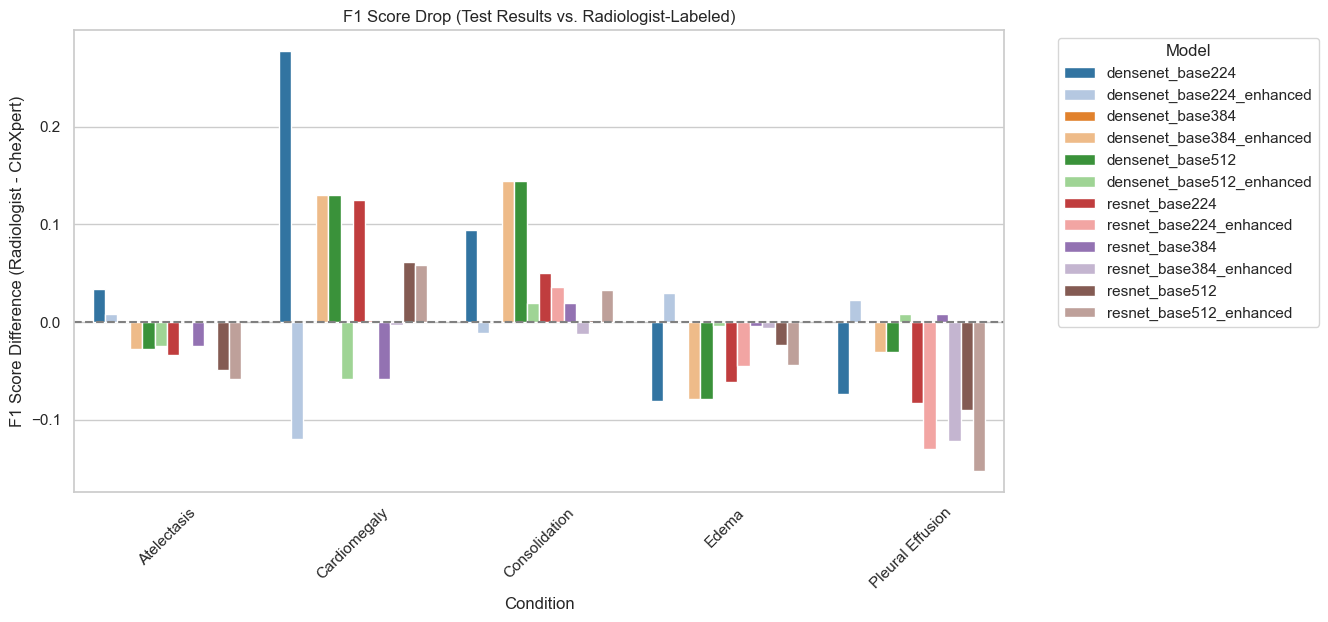

In [14]:
# Generate visualizations
plt.figure(figsize=(12,6))
sns.barplot(data=df_comparison, x="condition", y="F1 Score Diff", hue="model_name", hue_order=model_order, palette="tab20")

plt.axhline(0, color="gray", linestyle="dashed")  # Reference line at zero
plt.xticks(rotation=45)
plt.title("F1 Score Drop (Test Results vs. Radiologist-Labeled)")
plt.ylabel("F1 Score Difference (Radiologist - CheXpert)")
plt.xlabel("Condition")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

### Balanced Error Rate (BER) Comparison
This section compares **Balanced Error Rate (BER)** between **CheXpert-labeled test results** and the **radiologist-labeled dataset** to assess how well models generalize.

- **Lower BER is better**, indicating more accurate classification.
- **Comparing test vs. expert-labeled BER** helps determine **whether models overfit to CheXpert’s labels**.
- **Differences across conditions** provide insight into label quality and classification difficulty.

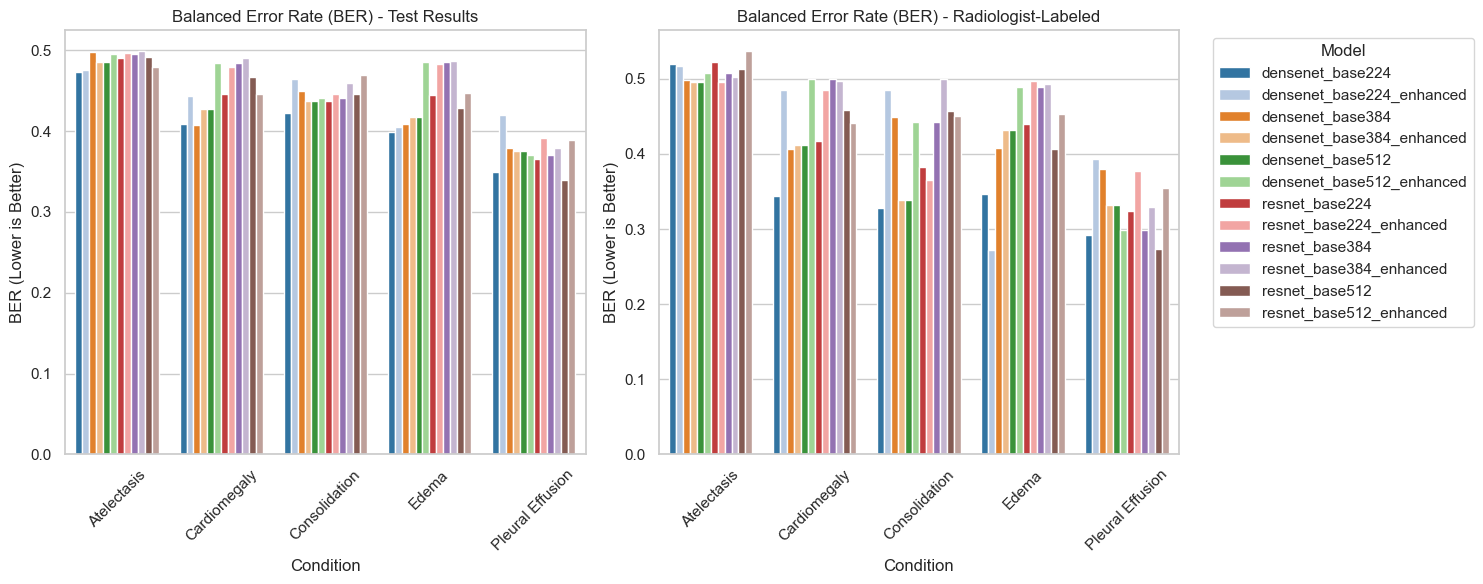

In [15]:
# Create subplots for BER comparison
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# BER for CheXpert-labeled test results
sns.barplot(data=df_test_pivot, x="condition", y="BER", hue="model_name", palette="tab20", ax=axes[0])
axes[0].set_title("Balanced Error Rate (BER) - Test Results")
axes[0].set_ylabel("BER (Lower is Better)")
axes[0].set_xlabel("Condition")
axes[0].tick_params(axis='x', rotation=45)

# BER for Radiologist-labeled test results
sns.barplot(data=df_test_rad_pivot, x="condition", y="BER", hue="model_name", palette="tab20", ax=axes[1])
axes[1].set_title("Balanced Error Rate (BER) - Radiologist-Labeled")
axes[1].set_ylabel("BER (Lower is Better)")
axes[1].set_xlabel("Condition")
axes[1].tick_params(axis='x', rotation=45)

# move legend outside of plot
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

# remove one of the legends
axes[0].get_legend().remove()

plt.tight_layout()

**Objective**: Measure **BER shift** when transitioning from CheXpert to radiologist labels.

- **Positive values**: Higher BER on radiologist labels, indicating potential **overfitting** to CheXpert’s labels.
- **Negative values**: Lower BER on radiologist labels, suggesting improved **generalization** to expert-annotated data.
- This visualization helps identify which models **generalize well** versus those that may be **biased toward CheXpert**.

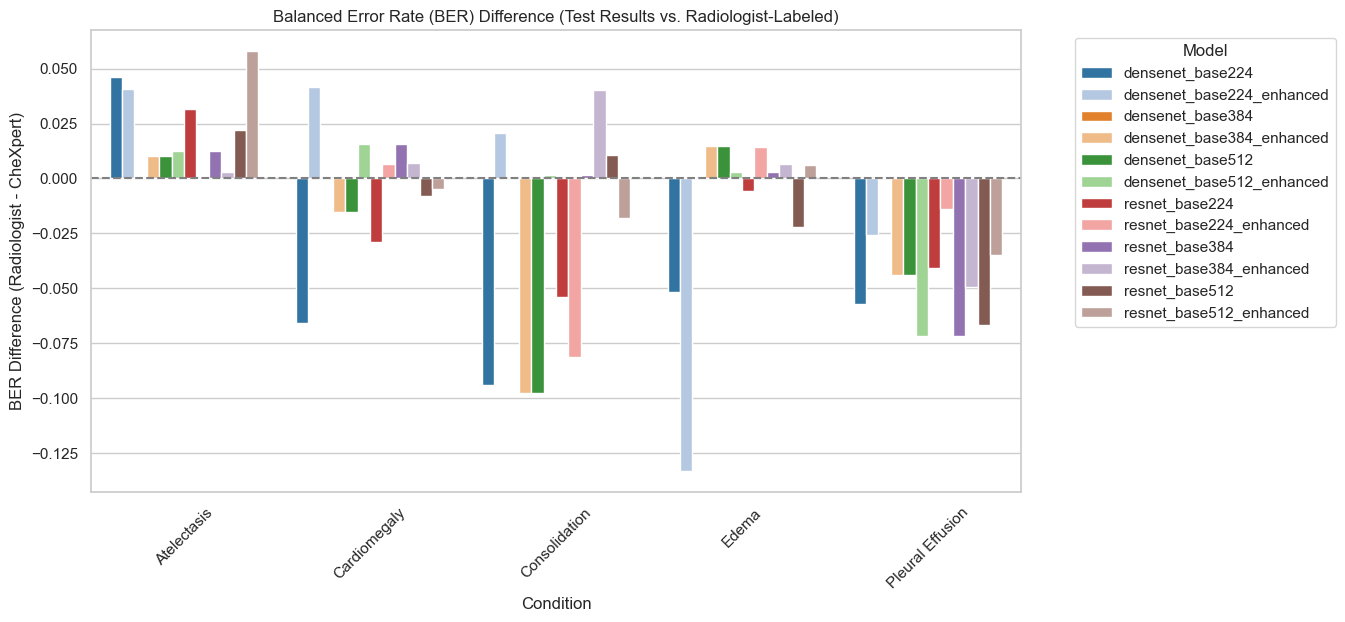

In [16]:
# Generate visualizations
plt.figure(figsize=(12,6))

# Sort by condition name alphabetically instead of BER Diff
df_comparison_sorted_ber = df_comparison.sort_values("condition")

sns.barplot(
    data=df_comparison_sorted_ber, 
    x="condition", 
    y="BER Diff", 
    hue="model_name", 
    hue_order=model_order, 
    palette="tab20"
)

plt.axhline(0, color="gray", linestyle="dashed")  # Reference line at zero
plt.xticks(rotation=45)
plt.title("Balanced Error Rate (BER) Difference (Test Results vs. Radiologist-Labeled)")
plt.ylabel("BER Difference (Radiologist - CheXpert)")
plt.xlabel("Condition")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

**Objective**: Provide a compact visualization of **BER shifts across all conditions and models**.

- **Color Interpretation**:
  - **Blue**: Lower BER on radiologist labels (**better generalization**).
  - **Red**: Higher BER on radiologist labels (**potential CheXpert bias**).
- This heatmap highlights **model performance consistency** across conditions.

Text(92.10937499999999, 0.5, '')

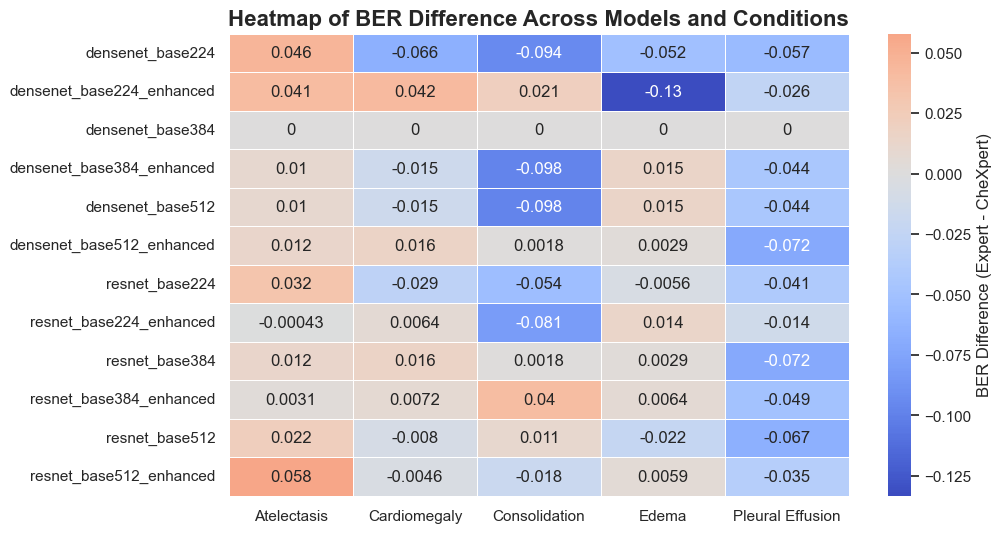

In [17]:
# Heatmap of BER Differences Across Models and Conditions
pivot_heatmap = df_comparison.pivot(index="model_name", columns="condition", values="BER Diff")

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_heatmap, 
    annot=True, 
    cmap="coolwarm", 
    center=0, 
    linewidths=0.5, 
    cbar_kws={'label': 'BER Difference (Expert - CheXpert)'}
)

plt.title("Heatmap of BER Difference Across Models and Conditions", fontweight="bold", fontsize=16)
# no x and y labels
plt.xlabel("")
plt.ylabel("")


### Precision and Recall Comparison
This section compares **Precision and Recall** between **CheXpert-labeled test results** and the **radiologist-labeled dataset** to assess how well models generalize.  

- **Higher Precision** indicates fewer false positives, meaning the model is more selective in its predictions.  
- **Higher Recall** suggests better sensitivity, meaning the model correctly identifies more positive cases.  
- **Comparing test vs. expert-labeled Precision and Recall** helps determine whether models are biased toward CheXpert labels or generalize well to expert annotations.  
- **Differences across conditions** highlight label quality and classification difficulty.  

By analyzing these metrics, we can identify which models strike the best balance between sensitivity and specificity for different conditions.

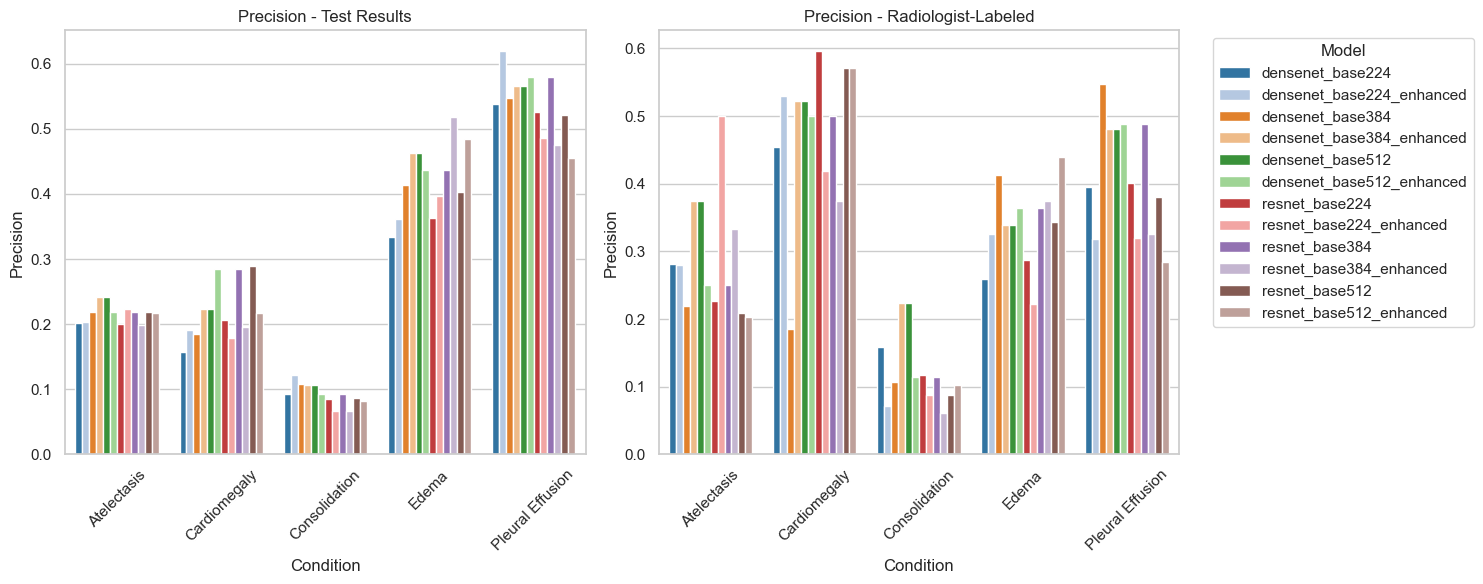

In [18]:
# Create subplots with 1 row and 2 columns for Precision comparison
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Plot Precision for test set (CheXpert-labeled)
sns.barplot(data=df_test_pivot, x="condition", y="Precision", hue="model_name", palette="tab20", ax=axes[0])
axes[0].set_title("Precision - Test Results")
axes[0].set_ylabel("Precision")
axes[0].set_xlabel("Condition")
axes[0].tick_params(axis='x', rotation=45)

# Plot Precision for radiologist-labeled test set (expert labels)
sns.barplot(data=df_test_rad_pivot, x="condition", y="Precision", hue="model_name", palette="tab20", ax=axes[1])
axes[1].set_title("Precision - Radiologist-Labeled")
axes[1].set_ylabel("Precision")
axes[1].set_xlabel("Condition")
axes[1].tick_params(axis='x', rotation=45)

# move legend outside of plot
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

# remove one of the legends
axes[0].get_legend().remove()

plt.tight_layout()

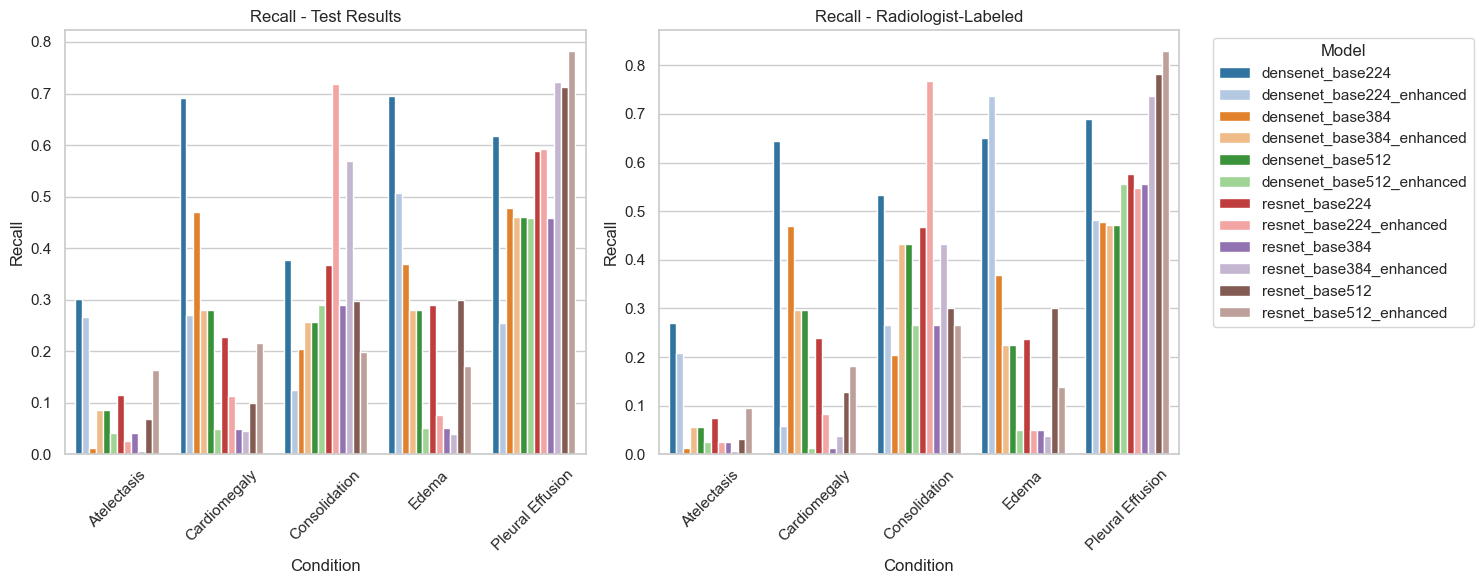

In [19]:
# Create subplots with 1 row and 2 columns for Recall comparison
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Plot Recall for test set (CheXpert-labeled)
sns.barplot(data=df_test_pivot, x="condition", y="Recall", hue="model_name", palette="tab20", ax=axes[0])
axes[0].set_title("Recall - Test Results")
axes[0].set_ylabel("Recall")
axes[0].set_xlabel("Condition")
axes[0].tick_params(axis='x', rotation=45)

# Plot Recall for radiologist-labeled test set (expert labels)
sns.barplot(data=df_test_rad_pivot, x="condition", y="Recall", hue="model_name", palette="tab20", ax=axes[1])
axes[1].set_title("Recall - Radiologist-Labeled")
axes[1].set_ylabel("Recall")
axes[1].set_xlabel("Condition")
axes[1].tick_params(axis='x', rotation=45)

# move legend outside of plot
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

# remove one of the legends
axes[0].get_legend().remove()

plt.tight_layout()

## Summary table
This section creates a summary table that aggregates the best-performing models across different metrics.

- Identify the top model per condition based on **F1 Score, BER, Precision, and Recall**.
- Compare differences in model performance across conditions.
- Evaluate consistency in model rankings across multiple evaluation metrics.

In [20]:
# Aggregate and transform data
df_test_pivot = df_test_pivot.reset_index(drop=True)
df_comparison = df_comparison.reset_index(drop=True)

# Extract the best models per condition for each metric
best_models_f1 = df_test_pivot.loc[df_test_pivot.groupby("condition")["F1 Score"].idxmax(), ["condition", "model_name", "F1 Score"]].reset_index(drop=True)
best_models_ber = df_test_pivot.loc[df_test_pivot.groupby("condition")["BER"].idxmin(), ["condition", "model_name", "BER"]].reset_index(drop=True)
best_models_precision = df_test_pivot.loc[df_test_pivot.groupby("condition")["Precision"].idxmax(), ["condition", "model_name", "Precision"]].reset_index(drop=True)
best_models_recall = df_test_pivot.loc[df_test_pivot.groupby("condition")["Recall"].idxmax(), ["condition", "model_name", "Recall"]].reset_index(drop=True)

# Rename columns for clarity
best_models_f1.rename(columns={"model_name": "Best Model (F1 Score)"}, inplace=True)
best_models_ber.rename(columns={"model_name": "Best Model (BER)"}, inplace=True)
best_models_precision.rename(columns={"model_name": "Best Model (Precision)"}, inplace=True)
best_models_recall.rename(columns={"model_name": "Best Model (Recall)"}, inplace=True)

# Merge all best model tables into a single summary table
summary_table = best_models_f1.merge(best_models_ber, on="condition", how="outer")
summary_table = summary_table.merge(best_models_precision, on="condition", how="outer")
summary_table = summary_table.merge(best_models_recall, on="condition", how="outer")

# Ensure df_comparison contains necessary columns for merging
df_comparison_reduced = df_comparison[["condition", "model_name", "F1 Score Diff", "BER Diff", "Precision Diff", "Recall Diff"]].reset_index(drop=True)

# Merge performance differences for the best models
summary_table = summary_table.merge(
    df_comparison_reduced, 
    left_on=["condition", "Best Model (F1 Score)"], 
    right_on=["condition", "model_name"], 
    how="left"
).drop(columns=["model_name"])

summary_table = summary_table.merge(
    df_comparison_reduced, 
    left_on=["condition", "Best Model (BER)"], 
    right_on=["condition", "model_name"], 
    how="left", 
    suffixes=("", "_BER")
).drop(columns=["model_name"])

summary_table = summary_table.merge(
    df_comparison_reduced, 
    left_on=["condition", "Best Model (Precision)"], 
    right_on=["condition", "model_name"], 
    how="left", 
    suffixes=("", "_Precision")
).drop(columns=["model_name"])

summary_table = summary_table.merge(
    df_comparison_reduced, 
    left_on=["condition", "Best Model (Recall)"], 
    right_on=["condition", "model_name"], 
    how="left", 
    suffixes=("", "_Recall")
).drop(columns=["model_name"])

# Select relevant columns for final summary table
summary_table = summary_table[[
    "condition", 
    "Best Model (F1 Score)", "F1 Score", "F1 Score Diff",
    "Best Model (BER)", "BER", "BER Diff",
    "Best Model (Precision)", "Precision", "Precision Diff",
    "Best Model (Recall)", "Recall", "Recall Diff"
]]

summary_table

metric,condition,Best Model (F1 Score),F1 Score,F1 Score Diff,Best Model (BER),BER,BER Diff,Best Model (Precision),Precision,Precision Diff,Best Model (Recall),Recall,Recall Diff
0,Atelectasis,densenet_base224,0.242221,0.033420,densenet_base224,0.473757,0.046110,densenet_base384_enhanced,0.241194,0.078985,densenet_base224,0.302305,-0.031865
1,Cardiomegaly,densenet_base384,0.265740,0.000000,densenet_base384,0.407248,0.000000,resnet_base512,0.289091,0.000000,densenet_base224,0.690401,0.000000
2,Consolidation,densenet_base384_enhanced,0.151146,0.144309,densenet_base224,0.422477,-0.097587,densenet_base224_enhanced,0.122333,0.116988,resnet_base224_enhanced,0.717778,0.176889
3,Edema,densenet_base224,0.450972,-0.080866,densenet_base224,0.398803,-0.051884,resnet_base384_enhanced,0.518939,-0.074875,densenet_base224,0.695850,-0.045850
4,Pleural Effusion,resnet_base512,0.602461,-0.090116,resnet_base512,0.339699,-0.066736,densenet_base224_enhanced,0.620257,-0.141003,resnet_base512_enhanced,0.783233,0.070281


In [21]:
summary_table_primary = summary_table[[
    "condition", 
    "Best Model (F1 Score)", "F1 Score", "F1 Score Diff",
    "Best Model (BER)", "BER", "BER Diff"
]]

summary_table_primary

metric,condition,Best Model (F1 Score),F1 Score,F1 Score Diff,Best Model (BER),BER,BER Diff
0,Atelectasis,densenet_base224,0.242221,0.033420,densenet_base224,0.473757,0.046110
1,Cardiomegaly,densenet_base384,0.265740,0.000000,densenet_base384,0.407248,0.000000
2,Consolidation,densenet_base384_enhanced,0.151146,0.144309,densenet_base224,0.422477,-0.097587
3,Edema,densenet_base224,0.450972,-0.080866,densenet_base224,0.398803,-0.051884
4,Pleural Effusion,resnet_base512,0.602461,-0.090116,resnet_base512,0.339699,-0.066736


In [22]:
summary_table_secondary = summary_table[[
    "condition", 
    "Best Model (Precision)", "Precision", "Precision Diff",
    "Best Model (Recall)", "Recall", "Recall Diff"
]]

summary_table_secondary

metric,condition,Best Model (Precision),Precision,Precision Diff,Best Model (Recall),Recall,Recall Diff
0,Atelectasis,densenet_base384_enhanced,0.241194,0.078985,densenet_base224,0.302305,-0.031865
1,Cardiomegaly,resnet_base512,0.289091,0.000000,densenet_base224,0.690401,0.000000
2,Consolidation,densenet_base224_enhanced,0.122333,0.116988,resnet_base224_enhanced,0.717778,0.176889
3,Edema,resnet_base384_enhanced,0.518939,-0.074875,densenet_base224,0.695850,-0.045850
4,Pleural Effusion,densenet_base224_enhanced,0.620257,-0.141003,resnet_base512_enhanced,0.783233,0.070281


### Best Model Selection Frequency Across Metrics

This section visualizes how frequently each model was selected as the **best-performing model** across different classification metrics.

- Identify which models consistently perform well across **F1 Score, BER, Precision, and Recall**.
- Understand whether certain architectures (e.g., DenseNet vs. ResNet) show dominance.
- Evaluate whether preprocessing influences model selection trends.

C:\Users\johnt\AppData\Local\Temp\ipykernel_17744\1757709357.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_counts, x="Model", y="Count", palette="tab10")


Text(0.5, 1.0, 'Best Model Selection Frequency Across Metrics')

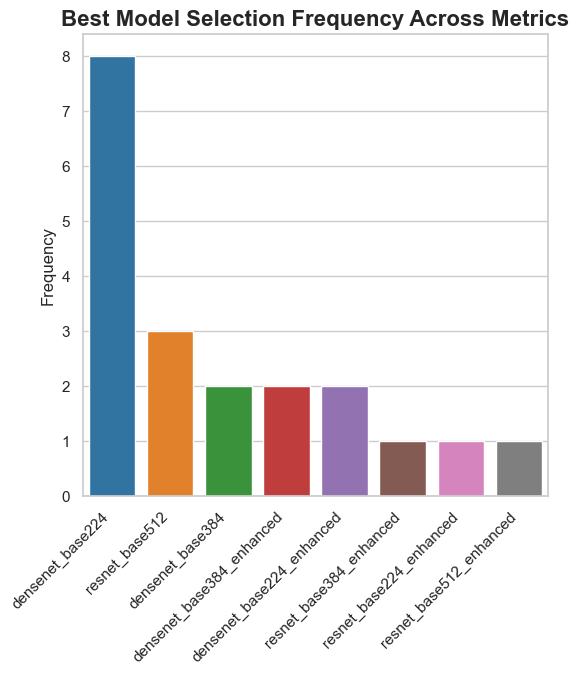

In [23]:
# Melting the summary table to count model occurrences
summary_table_melted = pd.melt(summary_table, 
                               id_vars=["condition"], 
                               value_vars=["Best Model (F1 Score)", "Best Model (BER)", 
                                           "Best Model (Precision)", "Best Model (Recall)"],
                               var_name="Metric", value_name="Model")

# Creating a frequency count of best model selections across different metrics
model_counts = summary_table_melted["Model"].value_counts().reset_index()
model_counts.columns = ["Model", "Count"]

# Creating the bar plot
plt.figure(figsize=(6, 6))
sns.barplot(data=model_counts, x="Model", y="Count", palette="tab10")

plt.xticks(rotation=45, ha="right")
plt.xlabel("")
plt.ylabel("Frequency")
plt.title("Best Model Selection Frequency Across Metrics", fontweight="bold", fontsize=16)